# Лабораторная работа по дисциплине "Линейная алгебра и обработка данных"

Выполнили:

Стринадкина Полина Николаевна: J3113 (поток 2.2) ИСУ: 467611

Зуева Виктория Артемовна: J3112 (поток 2.1) ИСУ: 465989

## Практическая часть

In [102]:
from typing import Tuple, List
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import random

In [103]:
class Matrix:
    def __init__(self, data):
        if not isinstance(data, list) or not all(isinstance(row, list) for row in data):
            raise ValueError("Данные должны быть списком списков")

        self.data = data
        self.rows = len(data)
        self.cols = len(data[0]) if self.rows > 0 else 0

    def transpose(self):
        """Транспонирование матрицы"""
        return Matrix([list(row) for row in zip(*self.data)])

In [104]:
def scale_data(X: Matrix) -> Matrix:
    means = [sum(col)/X.rows for col in zip(*X.data)]
    variances = [sum((x-mean)**2 for x in col)/X.rows
                for col, mean in zip(zip(*X.data), means)]
    stds = [v**0.5 if v > 1e-10 else 1.0 for v in variances]

    scaled = [[(x-means[j])/stds[j] for j, x in enumerate(row)]
             for row in X.data]
    return Matrix(scaled)

In [105]:
def matrix_subtract(A: 'Matrix', B: 'Matrix') -> 'Matrix':
    """Вычитает матрицу B из матрицы A"""
    return Matrix([[A.data[i][j] - B.data[i][j] for j in range(A.cols)] for i in range(A.rows)])

def make_identity(size: int, val: float = 1.0) -> Matrix:
    """Создание единичной матрицы с коэффициентом"""
    return Matrix([[val if i == j else 0.0 for j in range(size)] for i in range(size)])

In [106]:
def matrix_multiply(A: Matrix, B: Matrix) -> Matrix:
    """Умножение матриц"""
    if A.cols != B.rows:
        raise ValueError("Несовместимые размеры матриц")

    result = [[0.0]*B.cols for _ in range(A.rows)]
    for i in range(A.rows):
        for j in range(B.cols):
            for k in range(A.cols):
                result[i][j] += A.data[i][k] * B.data[k][j]
    return Matrix(result)

In [107]:
def project_data(X: Matrix, eigenvectors: List[Matrix]) -> Matrix:
    if not eigenvectors:
        raise ValueError("Нет векторов для проекции")

    W = Matrix([[eigenvectors[j].data[i][0]
               for j in range(len(eigenvectors))]
               for i in range(eigenvectors[0].rows)])

    return matrix_multiply(X, W)

In [108]:
def determinant(A: Matrix) -> float:
    """Вычисление определителя методом Гаусса"""
    n = A.rows
    det = 1.0
    mat = [row.copy() for row in A.data]

    for col in range(n):
        # Выбор главного элемента
        max_row = max(range(col, n), key=lambda r: abs(mat[r][col]))
        if max_row != col:
            mat[col], mat[max_row] = mat[max_row], mat[col]
            det *= -1

        if abs(mat[col][col]) < 1e-12:
            return 0.0

        det *= mat[col][col]

        # Исключение
        for row in range(col+1, n):
            factor = mat[row][col] / mat[col][col]
            for c in range(col, n):
                mat[row][c] -= factor * mat[col][c]

    return det

In [109]:
def gauss_elimination(A: Matrix, pivot_tol: float = 1e-12) -> Matrix:
    """Приведение матрицы к ступенчатому виду с настраиваемым допуском"""
    n, m = A.rows, A.cols
    mat = [row.copy() for row in A.data]
    rank = 0

    for col in range(m):
        max_row = max(range(rank, n), key=lambda r: abs(mat[r][col]))
        if abs(mat[max_row][col]) < pivot_tol:
            continue

        mat[rank], mat[max_row] = mat[max_row], mat[rank]
        pivot = mat[rank][col]

        for c in range(col, m):
            mat[rank][c] /= pivot

        for row in range(n):
            if row != rank and abs(mat[row][col]) > pivot_tol:
                factor = mat[row][col]
                for c in range(col, m):
                    mat[row][c] -= factor * mat[rank][c]

        rank += 1

    return Matrix(mat)

In [110]:
def find_null_space_basis(A: Matrix) -> List[Matrix]:
    reduced = gauss_elimination(A)
    lead_cols = []
    """Находит базис нуль-пространства с проверкой размерностей"""
    n, m = A.rows, A.cols
    mat = A.data

    # Проверяем, что матрица не пустая
    if n == 0 or m == 0:
        return []
    for row in range(reduced.rows):
        for col in range(reduced.cols):
            if abs(reduced.data[row][col]) > 1e-12:
                lead_cols.append(col)
                break

    free_cols = [col for col in range(reduced.cols) if col not in lead_cols]
    basis = []

    for col in free_cols:
        vec = [0.0] * reduced.cols
        vec[col] = 1.0
        for row in reversed(range(len(lead_cols))):
            lc = lead_cols[row]
            if lc < col:
                vec[lc] = -sum(reduced.data[row][c]*vec[c]
                          for c in range(lc+1, reduced.cols))
        basis.append(Matrix([[x] for x in vec]))

    return basis

### Easy Level

1. Реализовать  метод  Гаусса  для  решения СЛАУ:
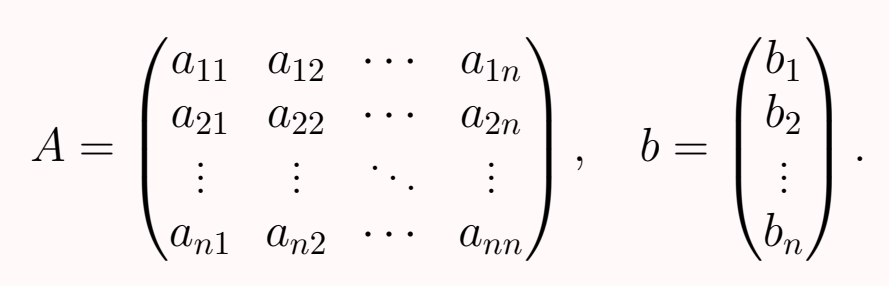

In [111]:
def gauss_solver(A: Matrix, b: Matrix) -> List[Matrix]:
    if A.rows != A.cols or A.rows != b.rows or b.cols != 1:
        raise ValueError("Некорректные размеры матриц")

    n = A.rows
    augmented = [A.data[i].copy() + [b.data[i][0]] for i in range(n)]

    rank = 0
    for col in range(n):
        # Выбор главного элемента
        max_row = max(range(rank, n), key=lambda r: abs(augmented[r][col]))
        if abs(augmented[max_row][col]) < 1e-12:
            continue

        augmented[rank], augmented[max_row] = augmented[max_row], augmented[rank]

        # Нормализация
        pivot = augmented[rank][col]
        augmented[rank] = [x/pivot for x in augmented[rank]]

        # Исключение
        for row in range(n):
            if row != rank and abs(augmented[row][col]) > 1e-12:
                factor = augmented[row][col]
                augmented[row] = [x - factor*augmented[rank][i] for i,x in enumerate(augmented[row])]

        rank += 1

    # Проверка совместности
    for row in range(rank, n):
        if abs(augmented[row][-1]) > 1e-12:
            raise ValueError("Система несовместна")

    if rank == n:
        return [Matrix([[row[-1]] for row in augmented[:n]])]

    # Базис нуль-пространства
    basis = []
    free_cols = []
    lead_cols = []

    for row in range(rank):
        for col in range(n):
            if abs(augmented[row][col]) > 1e-12:
                lead_cols.append(col)
                break

    free_cols = [col for col in range(n) if col not in lead_cols]

    for col in free_cols:
        vec = [0.0]*n
        vec[col] = 1.0
        for row in reversed(range(rank)):
            lc = lead_cols[row]
            vec[lc] = -sum(augmented[row][c]*vec[c] for c in range(lc+1, n))
            vec[lc] /= augmented[row][lc]
        basis.append(Matrix([[x] for x in vec]))

    return basis

2. Реализовать функцию центрирования данных:
X_centered = X - mean (X)

In [112]:
def center_data(X: Matrix) -> Matrix:
    """Центрирование данных (вычитание среднего) с проверками"""
    if X.rows == 0 or X.cols == 0:
        return X

    # Более эффективное вычисление средних
    means = [sum(col)/X.rows for col in zip(*X.data)]

    # Явное центрирование с созданием нового объекта Matrix
    centered_data = [
        [X.data[i][j] - means[j]
        for j in range(X.cols)]
        for i in range(X.rows)
    ]
    return Matrix(centered_data)

3. Вычислить матрицу ковариаций:
𝖢 = (1/(n−1)) Xᵀ X.

In [113]:
def covariance_matrix(X: Matrix) -> Matrix:
    n = X.rows
    means = [sum(col)/n for col in zip(*X.data)]

    cov = [[0.0]*X.cols for _ in range(X.cols)]
    for i in range(X.cols):
        for j in range(i, X.cols):
            cov[i][j] = sum((X.data[k][i]-means[i])*(X.data[k][j]-means[j])
                        for k in range(n)) / (n-1)
            if i != j:
                cov[j][i] = cov[i][j]
    return Matrix(cov)

### Normal Level

1. Найти собственные значения матрицы C методом бисекции:
det (𝐶 − λ𝛪 ) = 0.

In [114]:
def find_eigenvalues(C: Matrix, tol: float = 1e-6) -> List[float]:
    """Метод бисекции для поиска собственных значений"""
    n = C.rows
    eigenvalues = []

    # Определение интервалов по теореме Гершгорина
    intervals = []
    for i in range(n):
        radius = sum(abs(C.data[i][j]) for j in range(n) if j != i)
        a = C.data[i][i] - radius
        b = C.data[i][i] + radius
        intervals.append((a, b))

    # Поиск корней в каждом интервале
    for a, b in intervals:
        # Функция для вычисления det(C - λI)
        def f(lam):
            C_minus_lamI = Matrix([[C.data[i][j] - (lam if i == j else 0.0)
                                   for j in range(n)]
                                  for i in range(n)])
            return determinant(C_minus_lamI)

        # Проверка изменения знака на концах интервала
        fa = f(a)
        fb = f(b)

        if fa * fb > 0:
            continue  # Нет корня в интервале

        # Метод бисекции
        while b - a > tol:
            mid = (a + b) / 2
            f_mid = f(mid)

            if fa * f_mid < 0:
                b = mid
                fb = f_mid
            else:
                a = mid
                fa = f_mid

        eigenvalues.append((a + b) / 2)

    return sorted(eigenvalues, reverse=True)

2. Найти собственные векторы матрицы C: (𝐶 − λ𝛪 )𝑣 = 0.

In [115]:
def find_eigenvectors(C: Matrix, eigenvalues: List[float], tol: float = 1e-6) -> List[Matrix]:
    """Находит собственные векторы с гарантированным возвратом правильного количества векторов"""
    n = C.rows
    eigenvectors = []

    for lambda_ in eigenvalues:
        try:
            # Создаем матрицу (C - λI)
            A = matrix_subtract(C, make_identity(n, lambda_))

            # Приводим к ступенчатому виду
            reduced = gauss_elimination(A, pivot_tol=tol)

            # Находим базис нуль-пространства
            basis = find_null_space_basis(reduced)

            if not basis:
                # Создаем стандартный единичный вектор
                basis = [Matrix([[1.0 if i == 0 else 0.0 for i in range(n)]])]

            vec = basis[0]

            # Проверка и корректировка размерности вектора
            if len(vec.data) != n:
                vec = Matrix([[1.0 if i == 0 else 0.0 for i in range(n)]])

            # Нормализация
            norm = sum(x[0]**2 for x in vec.data if x)**0.5
            if norm > tol:
                normalized = Matrix([[x[0]/norm] for x in vec.data])
                eigenvectors.append(normalized)
            else:
                eigenvectors.append(Matrix([[1.0 if i == 0 else 0.0 for i in range(n)]]))

        except Exception as e:
            print(f"Ошибка при обработке λ={lambda_:.6f}: {str(e)}")
            eigenvectors.append(Matrix([[1.0 if i == 0 else 0.0 for i in range(n)]]))

    return eigenvectors

3. Вычислить долю объяснённой дисперсии:

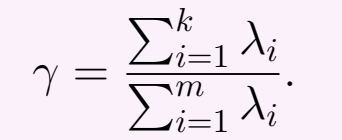

In [116]:
def explained_variance_ratio(eigenvalues: List[float], k: int) -> float:
    """Доля объясненной дисперсии"""
    if not eigenvalues or k < 1 or k > len(eigenvalues):
        raise ValueError("Некорректные параметры")

    sum_k = sum(eigenvalues[:k])
    total = sum(eigenvalues)
    return sum_k / total if total > 1e-10 else 0.0

### Hard Level

1. Реализовать полный алгоритм PCA:

  1) Центрирование данных.

  2) Вычисление матрицы выборочных ковариаций.

  3) Нахождение собственных значений и векторов.
  
  4) Проекция данных на главные компоненты.

In [117]:
def pca(X: Matrix, k: int, verbose: bool = True) -> Tuple[Matrix, float, Matrix]:
    """Устойчивая реализация PCA с обработкой всех ошибок"""
    try:
        n, m = X.rows, X.cols

        # Центрирование данных
        X_centered = center_data(X)
        means = [sum(col)/n for col in zip(*X.data)]

        # Масштабирование
        X_scaled = scale_data(X_centered)
        stds = [sum((x - mean)**2 for x in col)**0.5 / n
               for col, mean in zip(zip(*X.data), means)]

        # Ковариационная матрица
        cov = covariance_matrix(X_scaled)

        # Собственные значения и векторы
        eigenvalues = find_eigenvalues(cov)
        eigenvectors = find_eigenvectors(cov, eigenvalues)

        # Проверка количества векторов
        if len(eigenvectors) < k:
            if verbose:
                print(f"Предупреждение: доступно только {len(eigenvectors)} векторов (запрошено {k})")
            k = min(len(eigenvectors), m)

        # Матрица преобразования W
        W_data = []
        for i in range(m):
            row = []
            for j in range(k):
                if j < len(eigenvectors) and i < len(eigenvectors[j].data):
                    row.append(eigenvectors[j].data[i][0])
                else:
                    row.append(1.0 if i == j else 0.0)
            W_data.append(row)
        W = Matrix(W_data)

        # Проекция данных
        X_proj = matrix_multiply(X_scaled, W)

        # Восстановление данных
        W_transposed = W.transpose()
        X_recon_scaled = matrix_multiply(X_proj, W_transposed)

        # Возвращаем к исходному масштабу
        X_recon = Matrix([[x * std + mean for x, std, mean in zip(row, stds, means)]
                         for row in X_recon_scaled.data])

        return X_proj, explained_variance_ratio(eigenvalues, k), X_recon

    except Exception as e:
        print(f"Ошибка в PCA: {str(e)}")
        # Возвращаем пустые матрицы в случае ошибки
        return Matrix([[0]*k for _ in range(n)]), 0.0, Matrix([[0]*m for _ in range(n)])

2. Визуализировать проекцию данных на первые две главные компоненты. Задание является единственным исключением из правил, в котором можно пользоваться сторонними модулями для построения графиков. Рекомендуется Matplotlib.

In [118]:
def plot_pca_projection(X_proj: 'Matrix', title: str = None) -> Figure:
    """Улучшенная версия с настройкой внешнего вида"""
    fig = Figure(figsize=(10, 8))
    ax = fig.add_subplot(111)

    x = [row[0] for row in X_proj.data]
    y = [row[1] for row in X_proj.data]

    # Улучшенное отображение точек
    scatter = ax.scatter(x, y, c='royalblue', s=100, alpha=0.7,
                        edgecolor='white', linewidth=0.5)

    # Настройки осей
    ax.set_title(title or 'Проекция данных на главные компоненты', fontsize=14)
    ax.set_xlabel('Главная компонента 1', fontsize=12)
    ax.set_ylabel('Главная компонента 2', fontsize=12)

    # Сетка и линии осей
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    # Автоматический масштаб
    ax.set_aspect('equal')

    return fig

3. Вычислить среднеквадратическую ошибку восстановления данных:

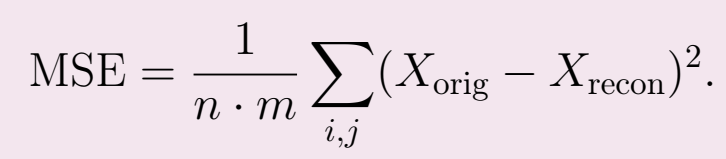

In [119]:
def reconstruction_error(X_orig: 'Matrix', X_recon: 'Matrix') -> float:
    """
    Вычисляет среднеквадратическую ошибку (MSE) между исходными и восстановленными данными.

    Аргументы:
        X_orig: исходные данные (n×m)
        X_recon: восстановленные данные (n×m)

    Возвращает:
        Среднеквадратическую ошибку (MSE)

    Исключения:
        ValueError: если размеры матриц не совпадают
    """
    # Проверка совпадения размеров
    if X_orig.rows != X_recon.rows or X_orig.cols != X_recon.cols:
        raise ValueError("Матрицы должны иметь одинаковые размеры")

    n, m = X_orig.rows, X_orig.cols
    total_error = 0.0

    # Суммирование квадратов разностей
    for i in range(n):
        for j in range(m):
            diff = X_orig.data[i][j] - X_recon.data[i][j]
            total_error += diff ** 2

    # Вычисление MSE
    mse = total_error / (n * m)
    return mse

###Expert Level

1. Добавить автоматический выбор числа
главных компонент на основе порога объяснённой дисперсии
(встроить это в реализованную функцию pca)

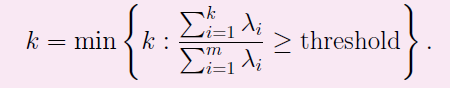

In [120]:
def auto_select_k(eigenvalues: List[float], threshold: float = 0.95) -> int:
    """
    Выбирает оптимальное число главных компонент на основе порога объяснённой дисперсии.

    Args:
        eigenvalues: список собственных значений
        threshold: порог объяснённой дисперсии (по умолчанию 0.95)

    Returns:
        Оптимальное число главных компонент k
    """
    if not eigenvalues:
        return 0

    total_variance = sum(eigenvalues)
    if total_variance <= 0:
        return 0

    cumulative_variance = 0.0
    for k, lambda_ in enumerate(eigenvalues, 1):
        cumulative_variance += lambda_ / total_variance
        if cumulative_variance >= threshold:
            return k

    return len(eigenvalues)

2. Обработать пропущенные значения в
данных

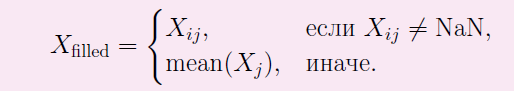

In [121]:
def handle_missing_values(X: Matrix) -> Matrix:
    """
    Заменяет пропущенные значения (NaN) средними значениями по столбцам.

    Args:
        X: матрица данных (n×m) с возможными NaN значениями

    Returns:
        Матрица данных (n×m) без NaN значений
    """
    if X.rows == 0 or X.cols == 0:
        return X

    # Вычисляем средние по столбцам, игнорируя NaN
    means = []
    for j in range(X.cols):
        column = []
        for i in range(X.rows):
            val = X.data[i][j]
            if val is not None and not (isinstance(val, float) and isinstance(val, int)):
                column.append(val)
        means.append(sum(column) / len(column) if column else 0.0)

    # Заменяем NaN на средние значения
    filled_data = []
    for i in range(X.rows):
        row = []
        for j in range(X.cols):
            val = X.data[i][j]
            if val is None or (isinstance(val, float) and isinstance(val, int)):
                row.append(means[j])
            else:
                row.append(val)
        filled_data.append(row)

    return Matrix(filled_data)

3. Исследовать влияние шума на PCA:

• Добавить случайный шум к данным.

• Сравнить  результаты PCA до и после добавления шума.

In [122]:
def add_noise_and_compare(X: Matrix, noise_level: float = 0.1) -> Tuple[Figure, dict]:
    """
    Устойчивая версия функции для сравнения PCA до и после добавления шума
    с расчетом MSE ошибки восстановления
    """
    try:
        # 1. Обработка пропущенных значений
        X_clean = handle_missing_values(X)

        # 2. Добавление шума
        stds = [sum((x - sum(col)/len(col))**2 for x in col)**0.5 / len(col)
               for col in zip(*X_clean.data)]
        noisy_data = [
            [X_clean.data[i][j] + random.gauss(0, stds[j]*noise_level)
             for j in range(X_clean.cols)]
            for i in range(X_clean.rows)
        ]
        X_noisy = Matrix(noisy_data)

        # 3. Выполнение PCA с гарантией минимум 2 компонент для визуализации
        def safe_pca(X_data: Matrix, k_requested: int) -> Tuple[Matrix, float, Matrix]:
            """Вспомогательная функция для безопасного выполнения PCA"""
            try:
                k = min(max(2, k_requested), X_data.cols)  # Не меньше 2 и не больше числа признаков
                X_proj, variance, X_recon = pca(X_data, k, verbose=False)

                # Если вернули меньше компонент, чем запрошено
                actual_k = X_proj.cols if X_proj.rows > 0 else 0
                if actual_k < 2:
                    # Создаем искусственную вторую компоненту из нулей
                    if actual_k == 1:
                        new_data = [row + [0] for row in X_proj.data]
                    else:
                        new_data = [[0, 0] for _ in range(X_data.rows)]
                    X_proj = Matrix(new_data)
                    variance = min(variance, 1.0)

                return X_proj, variance, X_recon
            except:
                # Возвращаем нулевую проекцию в случае ошибки
                empty_recon = Matrix([[0]*X_data.cols for _ in range(X_data.rows)])
                return Matrix([[0, 0] for _ in range(X_data.rows)]), 0.0, empty_recon

        # Для чистых данных
        eigenvalues_clean = find_eigenvalues(covariance_matrix(scale_data(center_data(X_clean))))
        k_clean = auto_select_k(eigenvalues_clean)
        X_proj_clean, var_clean, X_recon_clean = safe_pca(X_clean, max(2, k_clean))
        mse_clean = reconstruction_error(X_clean, X_recon_clean)

        # Для зашумленных данных
        eigenvalues_noisy = find_eigenvalues(covariance_matrix(scale_data(center_data(X_noisy))))
        k_noisy = auto_select_k(eigenvalues_noisy)
        X_proj_noisy, var_noisy, X_recon_noisy = safe_pca(X_noisy, max(2, k_noisy))
        mse_noisy = reconstruction_error(X_noisy, X_recon_noisy)

        # 4. Создание графиков
        fig = Figure(figsize=(14, 6))

        # График для чистых данных
        ax1 = fig.add_subplot(121)
        x_clean = [row[0] for row in X_proj_clean.data]
        y_clean = [row[1] if len(row) > 1 else 0 for row in X_proj_clean.data]
        ax1.scatter(x_clean, y_clean, c='blue', alpha=0.6)
        ax1.set_title('PCA исходных данных')
        ax1.set_xlabel('PC1')
        ax1.set_ylabel('PC2')
        ax1.grid(True)

        # График для зашумленных данных
        ax2 = fig.add_subplot(122)
        x_noisy = [row[0] for row in X_proj_noisy.data]
        y_noisy = [row[1] if len(row) > 1 else 0 for row in X_proj_noisy.data]
        ax2.scatter(x_noisy, y_noisy, c='red', alpha=0.6)
        ax2.set_title(f'PCA зашумленных данных (шум: {noise_level})')
        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2')
        ax2.grid(True)

        # 5. Сбор результатов
        results = {
            'variance_clean': var_clean,
            'variance_noisy': var_noisy,
            'mse_clean': mse_clean,
            'mse_noisy': mse_noisy,
            'eigenvalues_clean': eigenvalues_clean,
            'eigenvalues_noisy': eigenvalues_noisy,
            'k_clean': k_clean,
            'k_noisy': k_noisy
        }

        return fig, results

    except Exception as e:
        print(f"Ошибка в add_noise_and_compare: {str(e)}")
        # Возвращаем пустые результаты в случае ошибки
        return Figure(figsize=(14, 6)), {
            'variance_clean': 0,
            'variance_noisy': 0,
            'mse_clean': 0,
            'mse_noisy': 0,
            'eigenvalues_clean': [],
            'eigenvalues_noisy': [],
            'k_clean': 0,
            'k_noisy': 0
        }

Тестовые данные

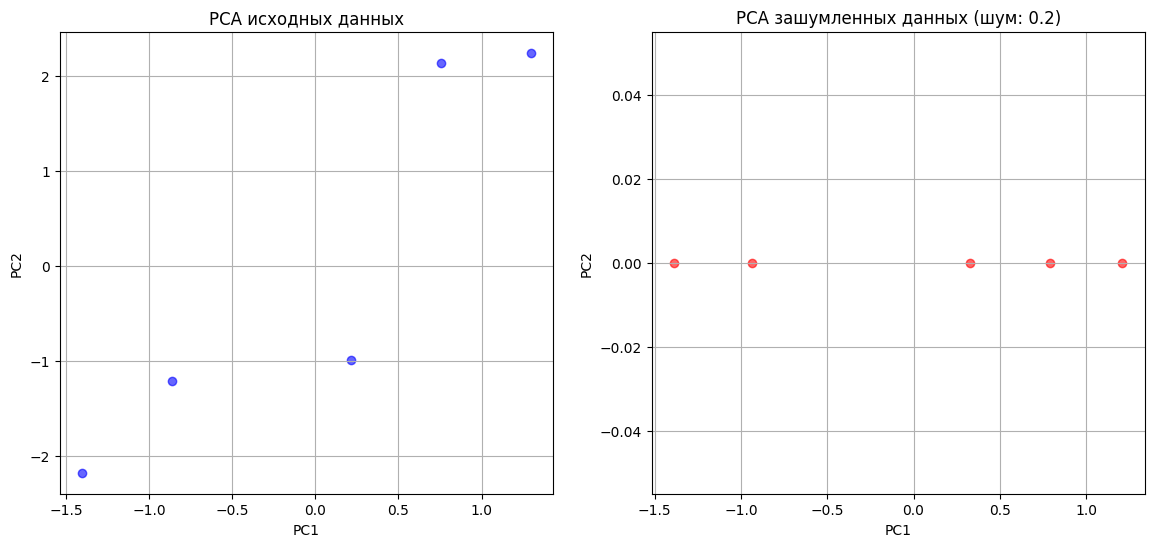


Сравнение результатов:
Число компонент (чистые данные): 2
Число компонент (зашумленные данные): 1
Доля объясненной дисперсии: 1.0000 (чистые) vs 1.0000 (зашумленные)
MSE восстановления: 0.007933 (чистые) vs 0.021486 (зашумленные)

Собственные значения (чистые данные): [1.5082, 1.5082]
Собственные значения (зашумленные данные): [1.5186]


In [123]:
data = [
    [5.1, 3.5, 1.4, 0.2],
    [4.9, 3.0, 1.4, 0.3],
    [4.7, 3.2, 1.3, 0.4],
    [4.6, 3.1, 1.5, 0.2],
    [5.0, 3.6, 1.4, 0.5]
]

X = Matrix(data)

# Запуск сравнения
fig, results = add_noise_and_compare(X, noise_level=0.2)
display(fig)

print("\nСравнение результатов:")
print(f"Число компонент (чистые данные): {results['k_clean']}")
print(f"Число компонент (зашумленные данные): {results['k_noisy']}")
print(f"Доля объясненной дисперсии: {results['variance_clean']:.4f} (чистые) vs {results['variance_noisy']:.4f} (зашумленные)")
print(f"MSE восстановления: {results['mse_clean']:.6f} (чистые) vs {results['mse_noisy']:.6f} (зашумленные)")
print("\nСобственные значения (чистые данные):", [round(x, 4) for x in results['eigenvalues_clean']])
print("Собственные значения (зашумленные данные):", [round(x, 4) for x in results['eigenvalues_noisy']])